<a href="https://colab.research.google.com/github/shraya06/DATA_ANALYTICS/blob/main/Crime%20Data%20prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("/content/Crime_Data_from_2020_to_Present.csv")  # replace with your file name
print(df.head())

       DR_NO        Date Rptd        DATE OCC  TIME OCC  AREA   AREA NAME  \
0  190326475    3/1/2020 0:00   3/1/2020 0:00    2130.0   7.0    Wilshire   
1  200106753    2/9/2020 0:00   2/8/2020 0:00    1800.0   1.0     Central   
2  200320258  11/11/2020 0:00  11/4/2020 0:00    1700.0   3.0   Southwest   
3  200907217   5/10/2023 0:00  3/10/2020 0:00    2037.0   9.0    Van Nuys   
4  200412582    9/9/2020 0:00   9/9/2020 0:00     630.0   4.0  Hollenbeck   

   Rpt Dist No  Part 1-2  Crm Cd                               Crm Cd Desc  \
0        784.0       1.0   510.0                          VEHICLE - STOLEN   
1        182.0       1.0   330.0                     BURGLARY FROM VEHICLE   
2        356.0       1.0   480.0                             BIKE - STOLEN   
3        964.0       1.0   343.0  SHOPLIFTING-GRAND THEFT ($950.01 & OVER)   
4        413.0       1.0   510.0                          VEHICLE - STOLEN   

   ... Status   Status Desc Crm Cd 1 Crm Cd 2  Crm Cd 3 Crm Cd 4  \


In [7]:
# Convert Date column to datetime
df['DATE OCC'] = pd.to_datetime(df['DATE OCC'])

# Extract Year and Month
df['Year'] = df['DATE OCC'].dt.year
df['Month'] = df['DATE OCC'].dt.month

# Check missing values
print(df.isnull().sum())

# Drop missing values (optional)
df = df.dropna()

DR_NO                 0
Date Rptd             1
DATE OCC              1
TIME OCC              1
AREA                  1
AREA NAME             1
Rpt Dist No           1
Part 1-2              1
Crm Cd                1
Crm Cd Desc           1
Mocodes            8823
Vict Age              1
Vict Sex           8525
Vict Descent       8527
Premis Cd             2
Premis Desc          32
Weapon Used Cd    43168
Weapon Desc       43168
Status                1
Status Desc           1
Crm Cd 1              3
Crm Cd 2          63989
Crm Cd 3          69437
Crm Cd 4          69607
LOCATION              1
Cross Street      56459
LAT                   1
LON                   1
Year                  1
Month                 1
dtype: int64


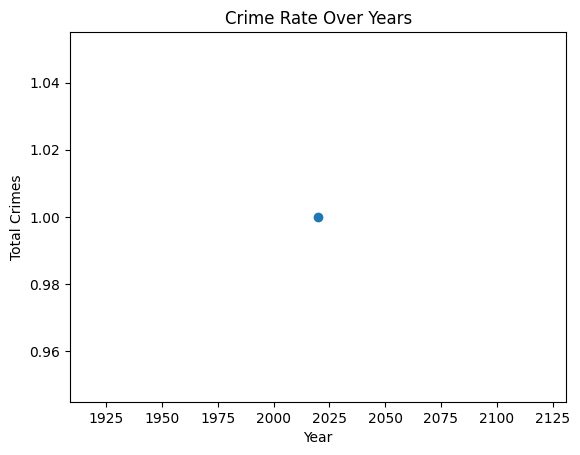

In [9]:
df['Count'] = 1
yearly_crime = df.groupby('Year')['Count'].sum()

plt.figure()
yearly_crime.plot(kind='line', marker='o')
plt.title("Crime Rate Over Years")
plt.xlabel("Year")
plt.ylabel("Total Crimes")
plt.show()

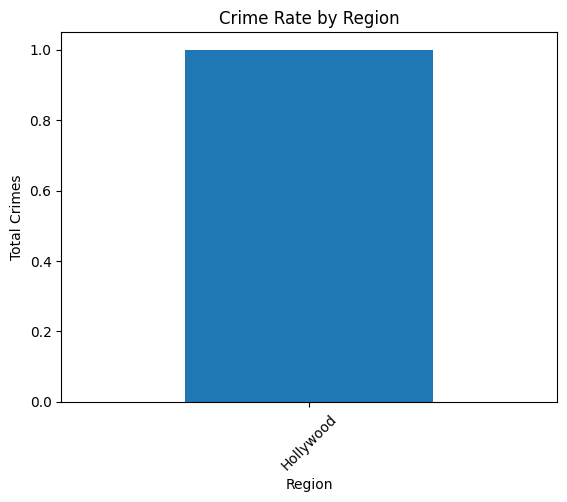

In [11]:
region_crime = df.groupby('AREA NAME')['Count'].sum().sort_values(ascending=False)

plt.figure()
region_crime.plot(kind='bar')
plt.title("Crime Rate by Region")
plt.xlabel("Region")
plt.ylabel("Total Crimes")
plt.xticks(rotation=45)
plt.show()

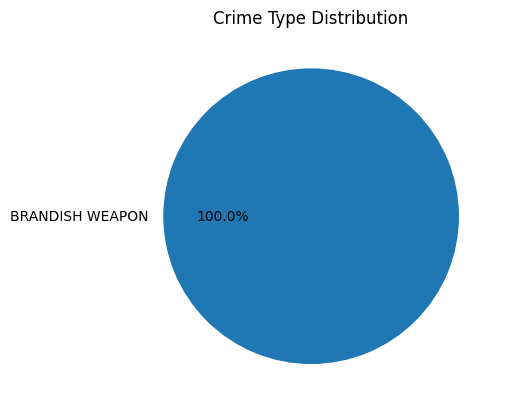

In [15]:
crime_type = df.groupby('Crm Cd Desc')['Count'].sum()

plt.figure()
crime_type.plot(kind='pie', autopct='%1.1f%%')
plt.title("Crime Type Distribution")
plt.ylabel("")
plt.show()

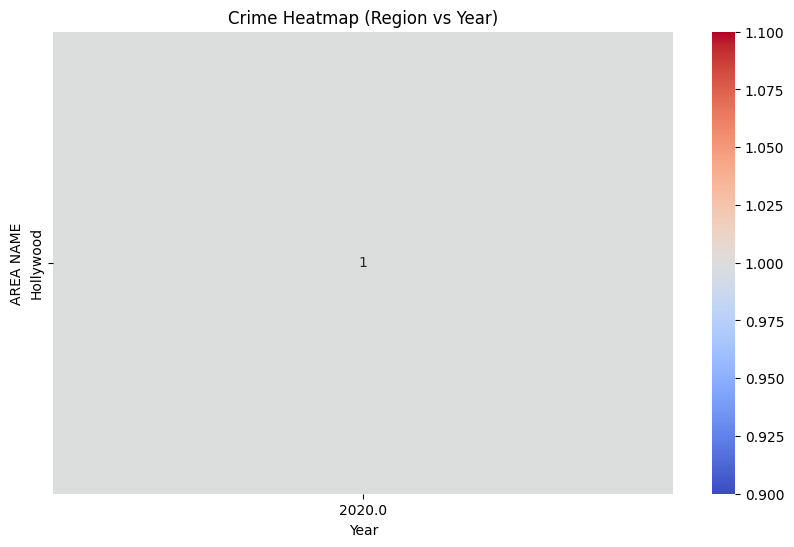

In [16]:
pivot_table = df.pivot_table(values='Count', index='AREA NAME', columns='Year', aggfunc='sum')

plt.figure(figsize=(10,6))
sns.heatmap(pivot_table, annot=True, cmap='coolwarm')
plt.title("Crime Heatmap (Region vs Year)")
plt.show()

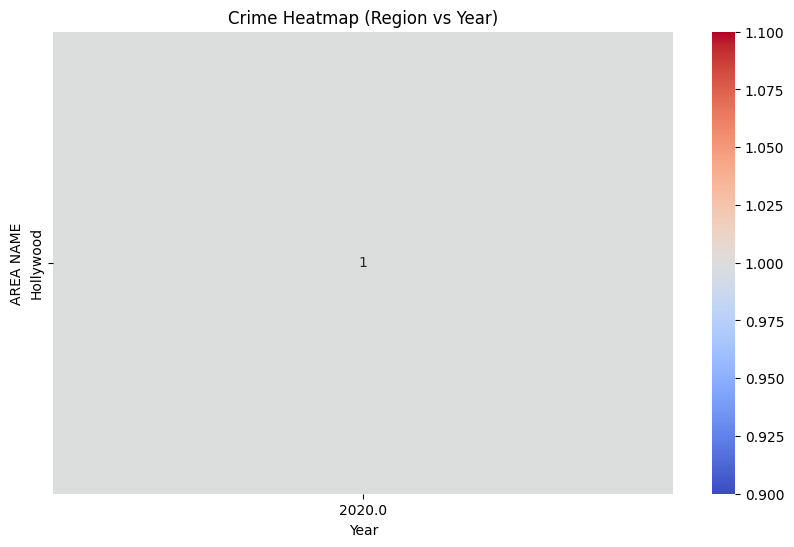

In [19]:
pivot_table = df.pivot_table(values='Count', index='AREA NAME', columns='Year', aggfunc='sum')

plt.figure(figsize=(10,6))
sns.heatmap(pivot_table, annot=True, cmap='coolwarm')
plt.title("Crime Heatmap (Region vs Year)")
plt.show()

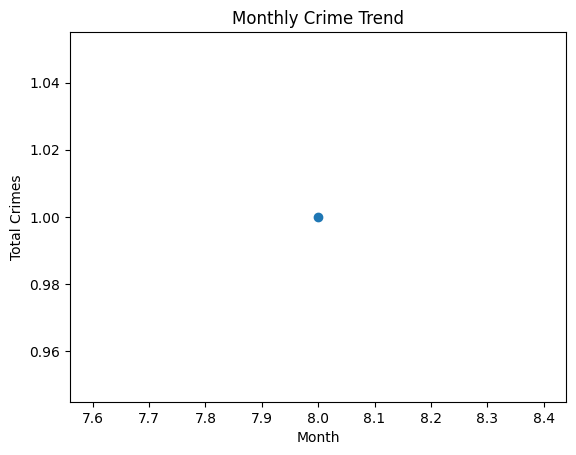

In [18]:
monthly_crime = df.groupby('Month')['Count'].sum()

plt.figure()
monthly_crime.plot(kind='line', marker='o')
plt.title("Monthly Crime Trend")
plt.xlabel("Month")
plt.ylabel("Total Crimes")
plt.show()